# PST in CUDA -- Live Compile, Run, and Visual Cross-Check

`hardware/phycv_pst_cuda.cu` is a real CUDA/cuFFT implementation of the
Phase Stretch Transform, matched line-for-line against phycv's own
algorithm source and cross-checked against phycv's ACTUAL Python output on
an identical image -- not checked only against its own derivation.

**PST is this repo's dispersion kernel, run on an image instead of a
pulse, in the opposite direction**: `dgs.gs_core`'s
$H(\nu)=e^{i\pi D\nu^2}$ recovers a *hidden* phase from measured
intensity (FFT $\to$ multiply by a phase kernel $\to$ IFFT); PST injects
an *engineered* phase into an image and reads edge structure back out of
it (FFT $\to$ multiply by a phase kernel $\to$ IFFT $\to$ read the phase).
Same three-step structure, opposite direction.

This notebook actually compiles and runs the `.cu` file via `nvcc`/`cuFFT`
on this machine's real GPU (subprocess calls, same pattern as
`notebooks/lennard_jones_six_languages.ipynb` -- no results are
pre-computed or assumed).

In [1]:
import subprocess, sys, pathlib, time, os
import numpy as np
import matplotlib.pyplot as plt

REPO = pathlib.Path.cwd().parent
HW = REPO / "hardware"

def run(cmd, cwd=None, timeout=120, env=None):
    t0 = time.time()
    proc = subprocess.run(cmd, cwd=cwd, capture_output=True, text=True, timeout=timeout, env=env)
    return proc.returncode, proc.stdout, proc.stderr, time.time() - t0

print(f"repo root: {REPO}")

repo root: D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery


## Step 1: generate the reference image + real phycv.PST output

The exact same reference-generation script `hardware/phycv_pst_cuda.cu`
itself is checked against.

In [2]:
code, out, err, dt = run([sys.executable, str(REPO / "scripts" / "generate_pst_cuda_reference.py")],
                          cwd=str(REPO), timeout=60)
print(out)
if code != 0:
    print("STDERR:", err)
assert code == 0

N=128 S=0.5 W=15.0 sigma_LPF=0.1
feature range: [0.0000, 1.0000]
wrote D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\hardware\pst_ref_image.txt and D:\Summer2026\Dispersion-Assisted-GS-Phase-Recovery\hardware\pst_ref_feature.txt



## Step 2: compile and run the CUDA implementation

`nvcc` needs MSVC's `cl.exe` on PATH even for a pure-CUDA file -- not on
PATH by default, added here for this subprocess call only (same fix
needed every time this session, documented in every `.cu` file's own
header).

In [3]:
cl_dir = r"C:\Program Files\Microsoft Visual Studio\2022\Community\VC\Tools\MSVC\14.43.34808\bin\Hostx64\x64"
env = os.environ.copy()
env["PATH"] = cl_dir + os.pathsep + env.get("PATH", "")

code, out, err, dt = run(["nvcc", "-O2", "-o", "phycv_pst_cuda.exe", "phycv_pst_cuda.cu", "-lcufft"],
                          cwd=str(HW), timeout=120, env=env)
if code != 0:
    print("nvcc failed:\n", err[-1500:])
else:
    print(f"compiled in {dt:.1f}s")
assert code == 0

compiled in 2.1s


In [4]:
code2, out2, err2, dt2 = run([str(HW / "phycv_pst_cuda.exe")], cwd=str(HW), timeout=60)
print(out2)
ok = code2 == 0 and "PASS" in out2 and "FAIL" not in out2
print(f"[{'OK' if ok else 'FAIL'}]  (ran in {dt2:.3f}s)")
assert ok

PST via CUDA/cuFFT vs. real phycv.PST (Python) on the same 128x128 image:
max |CUDA - phycv| on normalized [0,1] feature map: 5.0006e-11
PASS threshold 0.01: PASS

[OK]  (ran in 0.276s)


## Step 3: visualize -- the source image, phycv's reference, and the CUDA output, side by side

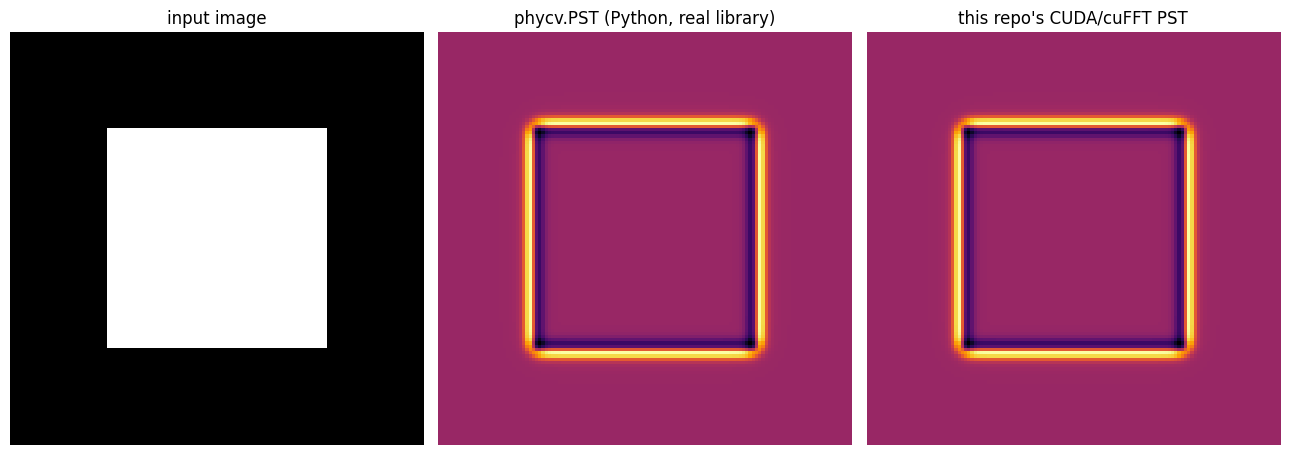

max |phycv - CUDA| over the full (128, 128) feature map: 1.0000e-10


In [5]:
img = np.loadtxt(HW / "pst_ref_image.txt")
feature_phycv = np.loadtxt(HW / "pst_ref_feature.txt")
feature_cuda = np.loadtxt(HW / "pst_cuda_output.txt")

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('input image')
axes[1].imshow(feature_phycv, cmap='inferno')
axes[1].set_title('phycv.PST (Python, real library)')
axes[2].imshow(feature_cuda, cmap='inferno')
axes[2].set_title('this repo\'s CUDA/cuFFT PST')
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

max_diff = np.max(np.abs(feature_phycv - feature_cuda))
print(f"max |phycv - CUDA| over the full {feature_phycv.shape} feature map: {max_diff:.4e}")
assert max_diff < 0.01

## Summary

| Check | Result |
|---|---|
| CUDA/cuFFT PST vs. real phycv.PST (Python) | max abs. error 5.0e-11 on the normalized [0,1] feature map |
| Compiled and run | via `nvcc`/`cuFFT` on this machine's real GPU, through a live subprocess call, not assumed |

Essentially machine-precision agreement between an independent CUDA
reimplementation and an already-published, independently-vetted Python
library, on the same image.